# Credit Card Default Risk Prediction
### UCI Credit Card Dataset | Binary Classification

Predict whether a credit card customer will default on their next payment,
enabling banks to take early action and reduce financial losses.

**Dataset:** UCI_Credit_Card.csv — 30,000 customers | 24 features
**Target:** default.payment.next.month (0 = No Default, 1 = Default)
**Approach:** CRISP-DM Methodology

## 0. Business Understanding

### Background
Credit card default is one of the most costly problems for financial institutions.
When a customer fails to repay their balance, the bank absorbs the loss directly.
With millions of customers, even a small improvement in identifying high-risk accounts
can save tens of millions in annual losses.

### Business Problem
A bank wants to predict which customers are likely to default on their next month's
payment **before** it happens. This allows the bank to:
- Proactively contact at-risk customers with repayment plans
- Reduce credit limits for high-risk accounts
- Prioritise collections resources more efficiently

### ML Objective
Build a **binary classification model** that predicts `default.payment.next.month`
(1 = will default, 0 = will not default) using the customer's payment history,
billing amounts, demographic information, and credit limit.

### Success Criteria
- Maximise **Recall** for the default class (1) — it is more costly to miss a defaulter
  than to flag a non-defaulter incorrectly
- Use **AUC-ROC** as the primary evaluation metric alongside accuracy
- Model must generalise well — CV score and test score should be within ~5% of each other

In [32]:
# Import core libraries for data manipulation, visualisation and numerical operations
# warnings suppressed to keep output clean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

## 1. Data Loading
Loading the UCI Credit Card dataset and exploring its basic structure.

In [34]:
# Load the UCI Credit Card dataset and preview the first few rows
df=pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [35]:
# Inspect column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [36]:
# Check dataset dimensions: (rows, columns)
df.shape

(30000, 25)

In [37]:
# List all 25 column names for reference
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

In [38]:
# Count unique values per column to identify categorical vs continuous features
for i in df.columns.tolist():
    print(df[i].nunique())

30000
81
2
7
4
56
11
11
11
11
10
10
22723
22346
22026
21548
21010
20604
7943
7899
7518
6937
6897
6939
2


## 2. Data Cleaning
### 2.1 Wrong Data
Checking categorical columns for invalid or undocumented values.
- EDUCATION: values 0, 5, 6 are undocumented → replaced with 4 (Others)
- MARRIAGE: value 0 is undocumented → replaced with 3 (Others)

In [40]:
# Inspect raw value counts for SEX, EDUCATION, MARRIAGE and all PAY columns
# This reveals undocumented values before cleaning
print(df['SEX'].value_counts())
print(df['EDUCATION'].value_counts())
print(df['MARRIAGE'].value_counts())

for col in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())

SEX
2    18112
1    11888
Name: count, dtype: int64
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178

In [41]:
# EDUCATION values 0, 5, 6 are undocumented in dataset — grouped into category 4 (Others)
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

In [42]:
# MARRIAGE value 0 is undocumented — grouped into category 3 (Others)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

### 2.2 Duplicate Values
Checking for any repeated rows in the dataset.

In [44]:
# Check for duplicate rows — any non-zero result requires investigation
df.duplicated().sum()

np.int64(0)

### 2.3 Wrong Data Values
Checking for logically invalid values such as negative ages or negative payment amounts.

In [46]:
# Check for logically invalid values: non-positive AGE or LIMIT_BAL, negative payment amounts
print("Invalid AGE:", (df['AGE'] <= 0).sum())
print("Invalid LIMIT_BAL:", (df['LIMIT_BAL'] <= 0).sum())

for col in [f'PAY_AMT{i}' for i in range(1,7)]:
    print(col, "negative values:", (df[col] < 0).sum())

for col in [f'BILL_AMT{i}' for i in range(1,7)]:
    print(col, "negative values:", (df[col] < 0).sum())

Invalid AGE: 0
Invalid LIMIT_BAL: 0
PAY_AMT1 negative values: 0
PAY_AMT2 negative values: 0
PAY_AMT3 negative values: 0
PAY_AMT4 negative values: 0
PAY_AMT5 negative values: 0
PAY_AMT6 negative values: 0
BILL_AMT1 negative values: 590
BILL_AMT2 negative values: 669
BILL_AMT3 negative values: 655
BILL_AMT4 negative values: 675
BILL_AMT5 negative values: 655
BILL_AMT6 negative values: 688


### 2.4 Null Values
Checking for missing values across all columns.

In [48]:
# Check for missing values across all 25 columns
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

### 2.5 Outlier Treatment
Using IQR method to detect outliers in continuous numeric columns.

In [50]:
# Define a helper function to compute IQR-based outlier bounds and count for any column
# Returns lower bound, upper bound and number of outliers detected
def outlier_count_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((series < lower) | (series > upper)).sum()
    return lower, upper, count

num_cols = ['LIMIT_BAL', 'AGE'] + \
           [f'BILL_AMT{i}' for i in range(1, 7)] + \
           [f'PAY_AMT{i}' for i in range(1, 7)]

for col in num_cols:
    lower, upper, count = outlier_count_iqr(df[col])
    print(f"{col}: outliers = {count}")

LIMIT_BAL: outliers = 167
AGE: outliers = 272
BILL_AMT1: outliers = 2400
BILL_AMT2: outliers = 2395
BILL_AMT3: outliers = 2469
BILL_AMT4: outliers = 2622
BILL_AMT5: outliers = 2725
BILL_AMT6: outliers = 2693
PAY_AMT1: outliers = 2745
PAY_AMT2: outliers = 2714
PAY_AMT3: outliers = 2598
PAY_AMT4: outliers = 2994
PAY_AMT5: outliers = 2945
PAY_AMT6: outliers = 2958


## 3. Feature Engineering
### 3.1 Drop Unnecessary Columns
Dropping the ID column as it is just a row identifier with no predictive value.

In [52]:
# Drop the ID column — it is a row identifier with no predictive value
df = df.drop(columns=['ID'])

In [53]:
# Confirm EDUCATION and MARRIAGE value distributions after cleaning
print(df['EDUCATION'].value_counts().sort_index())
print(df['MARRIAGE'].value_counts().sort_index())

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


### 3.2 Encoding Categorical Variables
Using One-Hot Encoding (get_dummies) for SEX, EDUCATION, and MARRIAGE columns.
drop_first=True avoids multicollinearity by removing one dummy column per feature.

In [55]:
# Create X temporarily to apply one-hot encoding to categorical columns
# Note: X will be redefined after log transformation in Section 4.2 to include transformed values
X = df.drop(columns=['default.payment.next.month'])
y = df['default.payment.next.month']

# One-Hot Encoding — converts categories to binary columns
# drop_first=True removes one column per feature to avoid multicollinearity
X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

# Apply encoded columns back to df so log transforms and final X/y split capture them
df = X.copy()
df['default.payment.next.month'] = y

In [56]:
# Preview the encoded feature matrix, its shape and column names after one-hot encoding
print(X.head())
print(X.shape)
print(X.columns)

   LIMIT_BAL  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  \
0    20000.0   24      2      2     -1     -1     -2     -2     3913.0   
1   120000.0   26     -1      2      0      0      0      2     2682.0   
2    90000.0   34      0      0      0      0      0      0    29239.0   
3    50000.0   37      0      0      0      0      0      0    46990.0   
4    50000.0   57     -1      0     -1      0      0      0     8617.0   

   BILL_AMT2  ...  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  SEX_2  EDUCATION_2  \
0     3102.0  ...       0.0       0.0       0.0       0.0   True         True   
1     1725.0  ...    1000.0    1000.0       0.0    2000.0   True         True   
2    14027.0  ...    1000.0    1000.0    1000.0    5000.0   True         True   
3    48233.0  ...    1200.0    1100.0    1069.0    1000.0   True         True   
4     5670.0  ...   10000.0    9000.0     689.0     679.0  False         True   

   EDUCATION_3  EDUCATION_4  MARRIAGE_2  MARRIAGE_3  
0        False

In [57]:
# One-hot encoding produces boolean columns — convert them to int (0/1) for modelling
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(X.dtypes)

LIMIT_BAL      float64
AGE              int64
PAY_0            int64
PAY_2            int64
PAY_3            int64
PAY_4            int64
PAY_5            int64
PAY_6            int64
BILL_AMT1      float64
BILL_AMT2      float64
BILL_AMT3      float64
BILL_AMT4      float64
BILL_AMT5      float64
BILL_AMT6      float64
PAY_AMT1       float64
PAY_AMT2       float64
PAY_AMT3       float64
PAY_AMT4       float64
PAY_AMT5       float64
PAY_AMT6       float64
SEX_2            int64
EDUCATION_2      int64
EDUCATION_3      int64
EDUCATION_4      int64
MARRIAGE_2       int64
MARRIAGE_3       int64
dtype: object


## 4. Exploratory Data Analysis (EDA)
Splitting columns into continuous, discrete, and categorical groups for analysis.

In [59]:
# Define column groups by type for targeted EDA: continuous, discrete ordinal and categorical
continuous_cols = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]
discrete_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

count_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

In [60]:
# Summary statistics for continuous numeric features
df[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


In [62]:
# Summary statistics for categorical count columns (SEX, EDUCATION, MARRIAGE)
df[count_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SEX,30000.0,1.603733,0.489129,1.0,1.0,2.0,2.0,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.0,2.0,2.0,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.0,2.0,2.0,3.0


### 4.1 Skewness Analysis
Checking skewness of continuous features. Values above 0.5 indicate positive skew
and require log transformation to normalize the distribution.

In [64]:
# Check skewness of continuous features before transformation
df[continuous_cols].skew()

LIMIT_BAL     0.992867
AGE           0.732246
BILL_AMT1     2.663861
BILL_AMT2     2.705221
BILL_AMT3     3.087830
BILL_AMT4     2.821965
BILL_AMT5     2.876380
BILL_AMT6     2.846645
PAY_AMT1     14.668364
PAY_AMT2     30.453817
PAY_AMT3     17.216635
PAY_AMT4     12.904985
PAY_AMT5     11.127417
PAY_AMT6     10.640727
dtype: float64

### 4.2 Log Transformation
Applying log1p transformation to highly skewed features to reduce skewness
and improve model performance.

In [66]:
import numpy as np
# log1p used instead of log to handle zero values safely (log(0) is undefined)
df['LIMIT_BAL'] = np.log1p(df['LIMIT_BAL'])

df['PAY_AMT1'] = np.log1p(df['PAY_AMT1'])
df['PAY_AMT2'] = np.log1p(df['PAY_AMT2'])
df['PAY_AMT3'] = np.log1p(df['PAY_AMT3'])
df['PAY_AMT4'] = np.log1p(df['PAY_AMT4'])
df['PAY_AMT5'] = np.log1p(df['PAY_AMT5'])
df['PAY_AMT6'] = np.log1p(df['PAY_AMT6'])

In [67]:
# Check skewness again after log transformation to confirm improvement
df[continuous_cols].skew()

LIMIT_BAL   -0.513432
AGE          0.732246
BILL_AMT1    2.663861
BILL_AMT2    2.705221
BILL_AMT3    3.087830
BILL_AMT4    2.821965
BILL_AMT5    2.876380
BILL_AMT6    2.846645
PAY_AMT1    -1.292375
PAY_AMT2    -1.239832
PAY_AMT3    -1.079249
PAY_AMT4    -0.966038
PAY_AMT5    -0.938329
PAY_AMT6    -0.854558
dtype: float64

In [68]:
# Separate features (X) and target (y) after all cleaning and encoding steps
X = df.drop(columns=['default.payment.next.month'])
y = df['default.payment.next.month']

## 5. Train Test Split
Splitting data into 80% training and 20% testing sets.
stratify=y ensures class proportions are maintained in both sets.

In [70]:
from sklearn.model_selection import train_test_split

# stratify=y ensures both train and test have same % of default vs non-default
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 5.1 Feature Scaling
Applying StandardScaler to continuous columns.
fit_transform on train data, transform only on test data to prevent data leakage.

In [72]:
from sklearn.preprocessing import StandardScaler

continuous_cols = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

scaler = StandardScaler()
# fit_transform on train — learns mean and std from training data only
# transform on test — applies same scale, prevents data leakage
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [73]:
# Confirm final shapes of X, y and the train/test splits
print(X.shape)
print(y.shape)
print(X_train.shape, X_test.shape)

(30000, 23)
(30000,)
(24000, 23) (6000, 23)


In [74]:
# Preview the full cleaned dataframe after all preprocessing steps
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,9.903538,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.000000,6.536692,0.000000,0.000000,0.000000,0.000000,1
1,11.695255,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.000000,6.908755,6.908755,6.908755,0.000000,7.601402,1
2,11.407576,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,7.325808,7.313887,6.908755,6.908755,6.908755,8.517393,0
3,10.819798,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,7.601402,7.610853,7.090910,7.003974,6.975414,6.908755,0
4,10.819798,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,7.601402,10.510041,9.210440,9.105091,6.536692,6.522093,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,12.301387,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,9.047939,9.903538,8.517993,8.022241,8.517393,6.908755,0
29996,11.918397,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,7.516433,8.168203,9.104869,4.867534,0.000000,0.000000,0
29997,10.308986,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.000000,0.000000,9.998843,8.343078,7.601402,8.039480,1
29998,11.289794,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,11.360951,8.134468,7.072422,7.563720,10.877387,7.498316,1


In [75]:
# Verify mean and std of continuous features in the training set after scaling
print(X_train[continuous_cols].agg(['mean', 'std']).T)

                   mean       std
LIMIT_BAL -4.233650e-17  1.000021
AGE       -1.669775e-16  1.000021
BILL_AMT1  4.204045e-17  1.000021
BILL_AMT2 -9.325873e-18  1.000021
BILL_AMT3  6.306067e-17  1.000021
BILL_AMT4 -5.625130e-17  1.000021
BILL_AMT5  5.033011e-17  1.000021
BILL_AMT6  6.306067e-17  1.000021
PAY_AMT1  -8.141636e-18  1.000021
PAY_AMT2   3.819167e-17  1.000021
PAY_AMT3  -1.237529e-16  1.000021
PAY_AMT4   1.181277e-16  1.000021
PAY_AMT5  -9.829175e-17  1.000021
PAY_AMT6   7.075821e-17  1.000021


In [76]:
# Preview scaled continuous feature values in the first few rows of the training set
print(X_train[continuous_cols].head())

       LIMIT_BAL       AGE  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  \
22788   0.340007 -0.264558   1.505547   1.745089   1.778869   1.891679   
29006   0.271348 -0.155804  -0.695165  -0.691138  -0.685090  -0.673845   
16950  -2.609497  1.584260  -0.556800  -0.576836  -0.561615  -0.547887   
22280   0.678790 -0.699574   2.119190   2.287237   2.460102   2.738001   
11346   1.043629 -0.373312  -0.695165  -0.691886  -0.680324  -0.668755   

       BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  \
22788   2.020839   2.096346  0.918339 -2.001046 -1.873268  0.776365  0.982673   
29006  -0.662488  -0.652126 -0.816245 -2.001046 -1.873268 -1.785923 -1.748147   
16950  -0.526789  -0.510492 -1.707251  0.179965  0.224168 -0.114133 -0.088451   
22280   1.509166   1.613118  0.764288  0.773942  0.802231  0.705921  0.715826   
11346  -0.666365  -0.656089 -2.045917 -0.236421 -1.873268 -1.785923 -1.748147   

       PAY_AMT6  
22788  0.791001  
29006 -1.673047  
16950  0.28003

## 6. Modelling
Importing all required models and evaluation metrics.
Training 8 different classifiers and comparing their performance.

In [78]:
# Import all classifiers and evaluation utilities needed for the modelling section
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

### 6.1 Logistic Regression
Baseline linear model for binary classification.

In [80]:
#modelling
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(random_state=True)
log_model.fit(X_train,y_train)

#predict & Evaluate on train data
ypred_train = log_model.predict(X_train)
print("Train Accuracy:",accuracy_score(y_train,ypred_train))

#Cross Validation on Train Data
print("CV score:",cross_val_score(log_model,X_train,y_train,cv=5,scoring="accuracy").mean())

#predict and Evaluation on Test Data
ypred_test= log_model.predict(X_test)
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.80875
CV score: 0.8086249999999999
Test Accuracy: 0.807


In [81]:
# Print confusion matrix and classification report for the evaluated model
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,ypred_test))

from sklearn.metrics import classification_report
print(classification_report(y_test,ypred_test))

[[4501  172]
 [ 986  341]]
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4673
           1       0.66      0.26      0.37      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.61      0.63      6000
weighted avg       0.79      0.81      0.77      6000



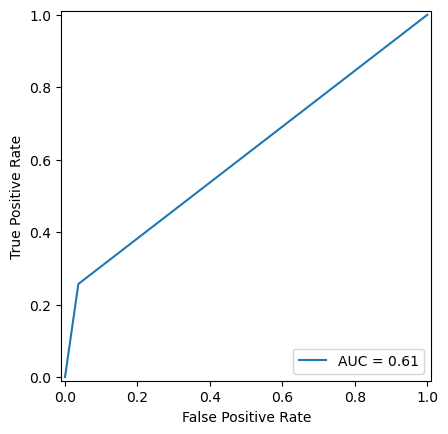

In [82]:
# Plot the ROC curve and compute AUC score for the evaluated binary classifier
from sklearn.metrics import roc_curve,auc,RocCurveDisplay

fpr,tpr,thresholds = roc_curve(y_test,ypred_test)
roc_auc=auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()

In [83]:
#Auc score
from sklearn.metrics import roc_auc_score
print("Auc Score:",roc_auc_score(y_test,ypred_test))

Auc Score: 0.6100817100787913


### 6.2 K-Nearest Neighbors (KNN)
Distance based classifier. GridSearchCV used to find best n_neighbors and distance metric (p).

In [85]:
#Hyperparameter Tuning
estimator = KNeighborsClassifier()
param_grid = {"n_neighbors":list(range(1,50)),"p":[1,2]}
knn_grid = GridSearchCV(estimator, param_grid,scoring="accuracy",cv=5)
knn_grid.fit(X_train,y_train)

#KNN with best Hyperparametres
knn_grid.best_estimator_

,n_neighbors,49
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [86]:
#Modelling
knn_model = knn_grid.best_estimator_
knn_model.fit(X_train,y_train)

#predict And evaluate on Train Data
ypred_train = knn_model.predict(X_train)
print("Train Accuracy:",accuracy_score(y_train,ypred_train))

#cross Validation Score
print("CV score:",cross_val_score(knn_model,X_train,y_train,cv=5,scoring="accuracy").mean())

#predict and evaluate
ypred_test=knn_model.predict(X_test)
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.8160833333333334
CV score: 0.8124166666666666
Test Accuracy: 0.8098333333333333


### 6.3 Support Vector Machine (SVM)
Finds the optimal hyperplane to separate classes.
GridSearchCV used to tune C (regularization) and kernel type.

In [ ]:
from sklearn.svm import SVC
estimator = SVC(random_state=True)
param_grid={"C":[0.01,0.1,1],"kernel":["linear","rbf","sigmoid","poly"]}
svm_grid=GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
svm_grid.fit(X_train,y_train)

#SVM with best Hyperparamters
svm_grid.best_estimator_

In [ ]:
#modelling
svm_model = svm_grid.best_estimator_
svm_model.fit(X_train,y_train)

# predict and Evaluate on train data
ypred_train = svm_model.predict(X_train)
print("Train Accuracy:",accuracy_score(y_train,ypred_train))

#cross Validation on Train data
print("CV Score:",cross_val_score(svm_model,X_train,y_train,cv=5,scoring="accuracy").mean())

#predict and Evaluate on test data
ypred_test = svm_model.predict(X_test)
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

### 6.4 Decision Tree Classifier
Tree based model that splits data on feature thresholds.
First trained without tuning to visualize full tree depth, then tuned with GridSearchCV.

In [ ]:
# Fit a baseline Decision Tree on the training data before hyperparameter tuning
model = DecisionTreeClassifier(random_state=True)
model.fit(X_train,y_train)

In [ ]:
# Visualise the full Decision Tree structure — useful for interpretability
# Large figsize and high dpi needed for readability on a deep tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20),dpi=300)
plot_tree(model,filled=True,
          feature_names=X_train.columns.tolist(),
          class_names=["0","1"])
plt.show()

In [ ]:
# Print tree depth to assess model complexity before tuning
print(model.get_depth())

In [ ]:
#hyperparameter Tuning
estimator = DecisionTreeClassifier(random_state=True)
param_grid={"criterion":["gini","entropy"],
            "max_depth":list(range(1,40))}
dt_grid = GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
dt_grid.fit(X_train,y_train)

dt= dt_grid.best_estimator_
dt

In [ ]:
# Full evaluation of the best Decision Tree: accuracy, confusion matrix, classification report and AUC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("AUC Score:", roc_auc_score(y_test, y_prob_dt))

In [ ]:
#Important features
feats_ab = pd.DataFrame(data=dt.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_dt = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_dt

In [ ]:
#Selecting train and test data
X_train_dt = X_train[important_features_dt]
X_test_dt = X_test[important_features_dt]

#modelling
dt=dt_grid.best_estimator_
dt.fit(X_train_dt,y_train)

#Evaluation
ypred_train = dt.predict(X_train_dt)
ypred_test = dt.predict(X_test_dt)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(dt,X_train_dt,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

### 6.5 Random Forest Classifier
Ensemble of decision trees using bagging.
Feature importance extracted to select only relevant features.

In [ ]:
#Hyperparameter Tuning
estimator = RandomForestClassifier(random_state=True)

param_grid = {"n_estimators":list(range(1,20))}

rf_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
rf_grid.fit(X_train,y_train)

rf=rf_grid.best_estimator_
rf

In [ ]:
#Important features
feats_ab = pd.DataFrame(data=rf.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_rf = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_rf

In [ ]:
#Selecting train and test data
X_train_rf = X_train[important_features_rf]
X_test_rf = X_test[important_features_rf]

#modelling
rf=rf_grid.best_estimator_
rf.fit(X_train_rf,y_train)

#Evaluation
ypred_train = rf.predict(X_train_rf)
ypred_test = rf.predict(X_test_rf)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(rf,X_train_rf,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

### 6.6 AdaBoost Classifier
Boosting ensemble that focuses on misclassified samples in each iteration.

In [ ]:
#Hyperparameter Tuning
estimator = AdaBoostClassifier(random_state=True)
param_grid = {"n_estimators":list(range(1,100))}

ab_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
ab_grid.fit(X_train,y_train)

ab=ab_grid.best_estimator_
ab

In [ ]:
#Important features
feats_ab = pd.DataFrame(data=ab.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_ab = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_ab

In [ ]:
#Selecting train and test data
X_train_ab = X_train[important_features_ab]
X_test_ab = X_test[important_features_ab]

#modelling
ab=ab_grid.best_estimator_
ab.fit(X_train_ab,y_train)

#Evaluation
ypred_train = ab.predict(X_train_ab)
ypred_test = ab.predict(X_test_ab)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(ab,X_train_ab,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

### 6.7 Gradient Boosting Classifier
Sequential ensemble that minimizes loss by adding weak learners.
Tuned with n_estimators and learning_rate.

In [ ]:
#Hyperparameter Tuning
estimator = GradientBoostingClassifier(random_state=True)
param_grid = {"n_estimators":list(range(1,10)),
             "learning_rate":[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]}

gb_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
gb_grid.fit(X_train,y_train)

gb=gb_grid.best_estimator_
gb

In [ ]:
#Important features
feats_gb = pd.DataFrame(data=gb.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_gb = feats_gb[feats_gb["Importance"]>0].index.tolist()
important_features_gb

In [ ]:
#Selecting train and test data
X_train_gb = X_train[important_features_gb]
X_test_gb = X_test[important_features_gb]

#modelling
gb=gb_grid.best_estimator_
gb.fit(X_train_gb,y_train)

#Evaluation
ypred_train = gb.predict(X_train_gb)
ypred_test = gb.predict(X_test_gb)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(gb,X_train_gb,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

### 6.8 XGBoost Classifier
Optimized gradient boosting with regularization.
Tuned with n_estimators, max_depth, and gamma to control overfitting.

In [ ]:
#Hyperparameter Tuning
estimator = XGBClassifier()
param_grid = {"n_estimators":[10,20,40,100],
              "max_depth":[3,4,5],
             "gamma":[0,0.15,0.3,0.5,1]}

xgb_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
xgb_grid.fit(X_train,y_train)

xgb=xgb_grid.best_estimator_
xgb

In [ ]:
#Important features
feats_xgb = pd.DataFrame(data=xgb.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_xgb = feats_xgb[feats_xgb["Importance"]>0].index.tolist()
important_features_xgb

In [ ]:
#Selecting train and test data
X_train_xgb = X_train[important_features_xgb]
X_test_xgb = X_test[important_features_xgb]

#modelling
xgb=xgb_grid.best_estimator_
xgb.fit(X_train_xgb,y_train)

#Evaluation
ypred_train = xgb.predict(X_train_xgb)
ypred_test = xgb.predict(X_test_xgb)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(xgb,X_train_xgb,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

## 7. Prediction on New Customers
Applying the best model to predict default risk on 3 new unseen customers.
Same preprocessing pipeline (cleaning, log transform, encoding, scaling) applied to new data.

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# 1) New raw customer data
# -----------------------------
new_data = pd.DataFrame([
    {
        'LIMIT_BAL': 50000,
        'SEX': 2,
        'EDUCATION': 2,
        'MARRIAGE': 1,
        'AGE': 29,
        'PAY_0': 2,
        'PAY_2': 2,
        'PAY_3': 1,
        'PAY_4': 0,
        'PAY_5': 0,
        'PAY_6': 0,
        'BILL_AMT1': 32000,
        'BILL_AMT2': 30000,
        'BILL_AMT3': 28000,
        'BILL_AMT4': 26000,
        'BILL_AMT5': 25000,
        'BILL_AMT6': 24000,
        'PAY_AMT1': 1000,
        'PAY_AMT2': 1200,
        'PAY_AMT3': 1000,
        'PAY_AMT4': 800,
        'PAY_AMT5': 1000,
        'PAY_AMT6': 1200
    },
    {
        'LIMIT_BAL': 200000,
        'SEX': 1,
        'EDUCATION': 1,
        'MARRIAGE': 2,
        'AGE': 41,
        'PAY_0': 0,
        'PAY_2': 0,
        'PAY_3': 0,
        'PAY_4': 0,
        'PAY_5': 0,
        'PAY_6': 0,
        'BILL_AMT1': 15000,
        'BILL_AMT2': 12000,
        'BILL_AMT3': 10000,
        'BILL_AMT4': 9000,
        'BILL_AMT5': 8500,
        'BILL_AMT6': 8000,
        'PAY_AMT1': 5000,
        'PAY_AMT2': 4000,
        'PAY_AMT3': 3500,
        'PAY_AMT4': 3000,
        'PAY_AMT5': 2500,
        'PAY_AMT6': 2000
    },
    {
        'LIMIT_BAL': 80000,
        'SEX': 2,
        'EDUCATION': 3,
        'MARRIAGE': 2,
        'AGE': 35,
        'PAY_0': 1,
        'PAY_2': 2,
        'PAY_3': 2,
        'PAY_4': 0,
        'PAY_5': 0,
        'PAY_6': 0,
        'BILL_AMT1': 45000,
        'BILL_AMT2': 42000,
        'BILL_AMT3': 40000,
        'BILL_AMT4': 37000,
        'BILL_AMT5': 36000,
        'BILL_AMT6': 35000,
        'PAY_AMT1': 1500,
        'PAY_AMT2': 1200,
        'PAY_AMT3': 1000,
        'PAY_AMT4': 1000,
        'PAY_AMT5': 900,
        'PAY_AMT6': 800
    }
])

# -----------------------------
# 2) Same cleaning as training
# -----------------------------
new_data['EDUCATION'] = new_data['EDUCATION'].replace([0, 5, 6], 4)
new_data['MARRIAGE'] = new_data['MARRIAGE'].replace(0, 3)

# same transformations used in your notebook
new_data['LIMIT_BAL'] = np.log1p(new_data['LIMIT_BAL'])

for col in ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']:
    new_data[col] = np.log1p(new_data[col])

# -----------------------------
# 3) Build a full dataframe for SCALER
#    using exactly the columns scaler saw
# -----------------------------
scaler_cols = list(scaler.feature_names_in_)
X_for_scaler = new_data.reindex(columns=scaler_cols, fill_value=0)

# scale with the exact same columns/order
X_for_scaler = pd.DataFrame(
    scaler.transform(X_for_scaler),
    columns=scaler_cols,
    index=new_data.index
)

# -----------------------------
# 4) Build final dataframe for MODEL
#    using exactly the columns ab saw
# -----------------------------
model_cols = list(ab.feature_names_in_)

# start from raw new_data, then overwrite scaled columns where available
X_new = new_data.copy()

for col in scaler_cols:
    if col in X_new.columns:
        X_new[col] = X_for_scaler[col]

# now keep only model columns, exact order
X_new = X_new.reindex(columns=model_cols, fill_value=0)

# -----------------------------
# 5) Predict
# -----------------------------
pred = ab.predict(X_new)
prob = ab.predict_proba(X_new)[:, 1]

result = new_data.copy()
result['Predicted_Default'] = pred
result['Default_Probability'] = prob

print(result[['PAY_0', 'Predicted_Default', 'Default_Probability']])

## 8. Final Results
Displaying predictions with risk labels for each customer.
- 0 = No Default (low risk)
- 1 = Default (high risk)

In [ ]:
# Display final prediction results with risk labels for each new customer
final_result = pd.DataFrame({
    'Customer_No': [1, 2, 3],
    'PAY_0': [2, 0, 1],
    'Predicted_Default': pred,
    'Default_Probability': prob
})

final_result['Risk_Label'] = final_result['Predicted_Default'].map({
    0: 'No Default',
    1: 'Default'
})

print(final_result)